# 05 — Twin dashboard: สภาพห้องบนโมเดล 3 มิติ ย้อนเวลาได้ (L2)

ทุกอย่างในหน้านี้เป็นเมธอดของ **`DigitalTwin`** (`pfal_twin/twin.py`) ซึ่งรวมทุกชั้นของ twin ไว้ในวัตถุเดียว:
`state(t)` · `figure_3d(t)` / `show(t)` · `snapshot(t)` · `heatmap()` · `kpi()` · `events()` · `layout_figure()` · `water_plan()` · `flow_diagram()` · `flow_animation()` · `update_data()`

> จุดวัด T/RH ในห้องปลูกมี 3 จุดบนผนังฝั่งแอร์ (xy_md_21/22/23) + ห้องหน้า (20) + นอกห้อง (24) — rack ระบายสีด้วยค่าเฉลี่ย 3 จุดในห้อง; ช่วงที่ gateway offline แสดงเป็นสีเทา "no data" 

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


## 1. โหลด twin (geometry + zones + layout + pipework + IoT + พารามิเตอร์ L3)

In [2]:
from pfal_twin.twin import DigitalTwin
twin = DigitalTwin.load()
print(twin.summary())

room 7.12 x 3.01 x 2.58 m | rack 5.43 x 1.04 m, 5 tiers | zones 14
equipment 29 items (28 verified) | sensors 10 | pipe edges 42
IoT 2025-12-26 -> 2026-09-14 18:30, 37,772 x 10-min bins, room T/RH in 3,536 bins


## 2. Heatmap จุดวัด × เวลา

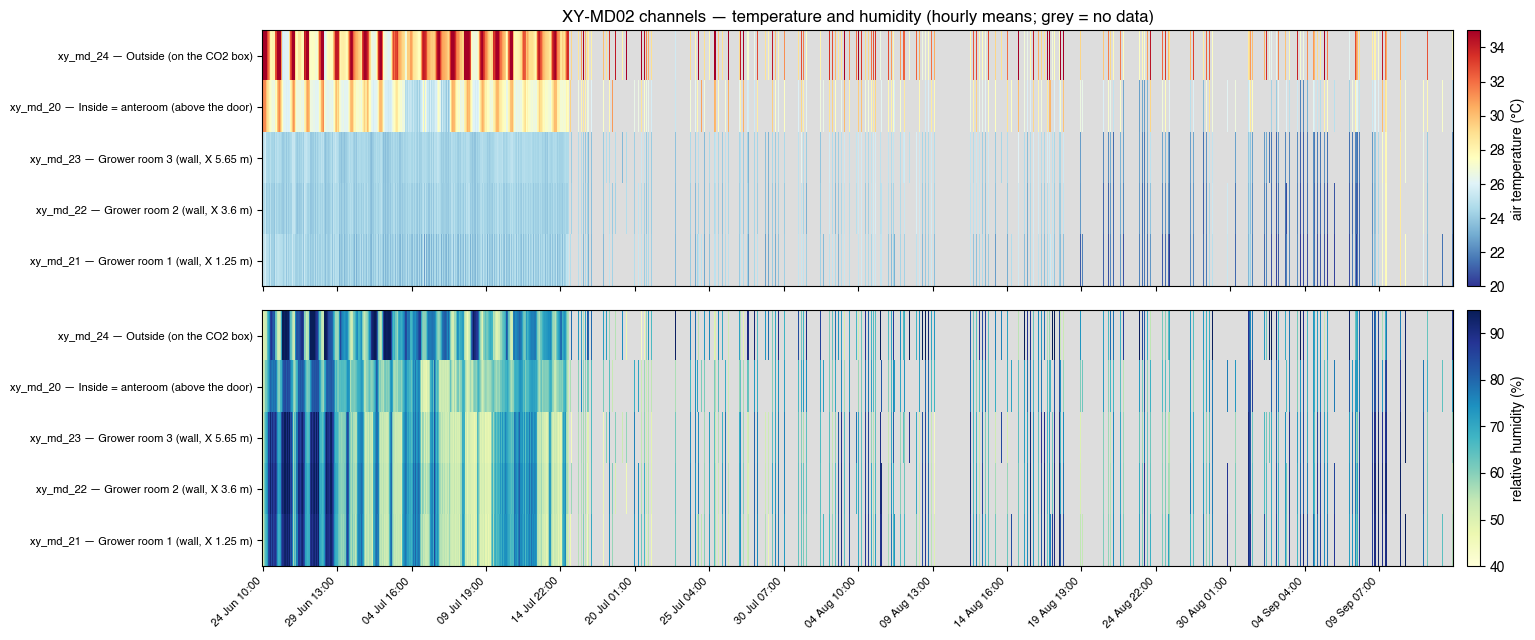

In [3]:
twin.heatmap(path=FIG / "05_channel_heatmap.png");

## 3. KPI ต่อจุดวัด + เหตุการณ์ค่าออกนอกช่วง (บันทึก `iot_events.csv`)

In [4]:
display(twin.kpi())
events_df = twin.events(); print(f"{len(events_df)} events"); events_df.groupby("event")["hours"].agg(["count", "sum"]).round(1)

,location,zone,T mean °C,T max °C,hours T > 30 °C,RH mean %,hours RH > 85 %,VPD mean kPa,hours VPD out of range,data hours
channel,,,,,,,,,,
xy_md_21,"Grower room 1 (wall, X 1.25 m)",room,24.17,30.6,0.33,67.19,79.17,0.99,95.00,575.17
xy_md_22,"Grower room 2 (wall, X 3.6 m)",room,24.26,30.6,0.33,67.67,79.17,0.98,95.17,573.83
xy_md_23,"Grower room 3 (wall, X 5.65 m)",room,24.41,31.0,0.33,66.50,74.67,1.02,97.83,572.00
xy_md_20,Inside = anteroom (above the door),anteroom,27.33,32.7,53.83,65.66,3.83,1.27,122.33,573.50
xy_md_24,Outside (on the CO2 box),outside,30.69,38.0,297.50,71.47,98.83,1.37,280.17,574.17


613 events


,count,sum
event,,
growing 200 L pH outside 5.5–6.5,174,838.9
growing 200 L |EC − setpoint| > 0.3,42,114.3
nursery-2 100 L pH outside 5.5–6.5,227,1022.5
nursery-2 100 L |EC − setpoint| > 0.3,48,662.3
xy_md_21 (room) RH > 85 %,41,61.6
xy_md_22 (room) RH > 85 %,43,64.1
xy_md_23 (room) RH > 85 %,38,59.8


## 4. สถานะ ณ เวลาใดๆ → ภาพ 3 มิติ (rack = ค่าเฉลี่ย 3 จุดในห้อง, จุดวัดระบายสีตามค่าจริง, ท่อทึบ = ปั๊มทำงาน)

In [5]:
t_hot = twin.warmest_moment()
st = twin.state(t_hot); print(f"warmest in-room moment with full data: {st.time:%Y-%m-%d %H:%M} — room {st.room_T:.1f} °C, outside {st.ch_T['xy_md_24']:.1f} °C, CO₂ {st.co2:.0f} ppm, EC growing {st.ec['growing (gc1)']:.2f}")
twin.show(t_hot, "T", name="05_twin_snapshot")

warmest in-room moment with full data: 2026-06-26 14:00 — room 25.8 °C, outside 36.3 °C, CO₂ 1223 ppm, EC growing 1.22


full-window version: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/05_twin_snapshot.html   (open in a browser)


PosixPath('/Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/05_twin_snapshot.html')

## 5. Time slider — เลื่อนดูย้อนหลัง (เฉพาะช่วงที่มีข้อมูลในห้อง)

In [6]:
import ipywidgets as widgets
times = twin.T.index[twin.has_room][::3]      # every 30 min
slider = widgets.SelectionSlider(options=[(t.strftime("%d %b %H:%M"), t) for t in times], value=times[-1],
                                 description="time", layout=widgets.Layout(width="90%"), continuous_update=False)
var = widgets.ToggleButtons(options=["T", "RH", "VPD"], description="variable")
def _show(t, var):
    rng = {"T": (20, 35), "RH": (40, 95), "VPD": (0, 2.5)}[var]
    twin.show(t, var, cmin=rng[0], cmax=rng[1])
widgets.interact(_show, t=slider, var=var);

interactive(children=(SelectionSlider(continuous_update=False, description='time', index=1178, layout=Layout(w…

## 6. Snapshot 2 มิติสำหรับบทความ

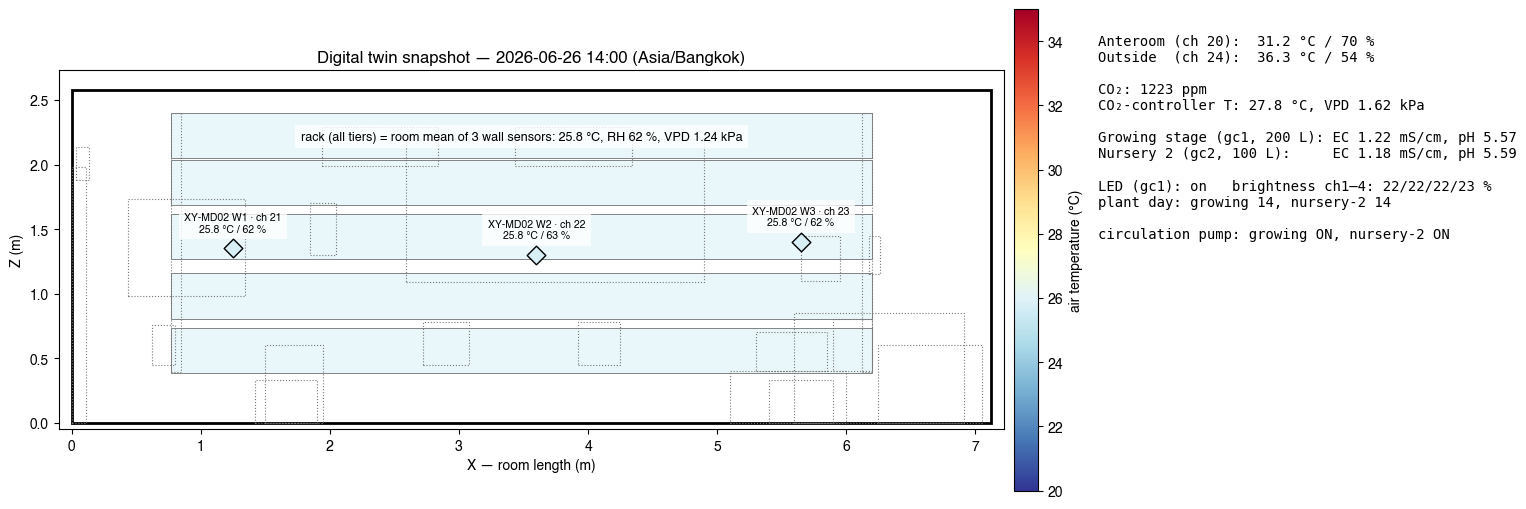

In [7]:
twin.snapshot(t_hot, path=FIG / "05_twin_snapshot.png");

## สรุป / ข้อจำกัด
- twin L2 ใช้งานได้ผ่าน API เดียว — เปิดเป็นเว็บให้ทีมดู: `.venv/bin/voila notebooks/05_twin_dashboard.ipynb`
- ในห้องปลูกมีจุดวัด T/RH แค่ 3 จุดบนผนังฝั่งแอร์ที่ 1.35 ม. — ไม่มีค่าที่ระดับใบพืชหรือฝั่งหน้าต่าง → ควรเพิ่ม XY-MD02 ในชั้นปลูก
- ยังไม่มี PPFD/DLI และพลังงาน (kWh) จากเซ็นเซอร์ — เป็น input ที่ต้องเก็บเพิ่มสำหรับ L3 (notebook 06)